Install & Import

In [1]:
!pip install scikit-learn tensorflow joblib pyyaml

In [2]:
import os
import json
import yaml
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras import layers, models

Mount Drive & Load Dataset

In [3]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
file_path = "/content/drive/MyDrive/SCIQUS_Internship/Datasets/telecom_churn.csv"

data = pd.read_csv(file_path)

if "Customer_ID" not in data.columns:
    data["Customer_ID"] = ["CUST_" + str(i) for i in range(len(data))]

print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (3333, 11)


,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins,Customer_ID
0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0,CUST_0
1,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7,CUST_1
2,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2,CUST_2
3,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6,CUST_3
4,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1,CUST_4


Preprocessing

In [50]:
data_numeric = data.select_dtypes(include=[np.number]).dropna()

feature_columns = data_numeric.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_numeric)

print("Processed Shape:", X_scaled.shape)

Processed Shape: (3333, 10)


Autoencoder

In [51]:
input_dim = X_scaled.shape[1]

encoder = models.Sequential([
    layers.Dense(16, activation="relu", input_shape=(input_dim,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(4, activation="relu")
])

decoder = models.Sequential([
    layers.Dense(8, activation="relu", input_shape=(4,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(input_dim)
])

autoencoder = models.Sequential([encoder, decoder])
autoencoder.compile(optimizer="adam", loss="mse")

history = autoencoder.fit(
    X_scaled, X_scaled,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 1.0196 - val_loss: 0.9311
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9129 - val_loss: 0.8419
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8177 - val_loss: 0.7710
Epoch 4/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7655 - val_loss: 0.6733
Epoch 5/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6463 - val_loss: 0.5970
Epoch 6/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5785 - val_loss: 0.5770
Epoch 7/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5565 - val_loss: 0.5649
Epoch 8/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5432 - val_loss: 0.5527
Epoch 9/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5185 - val_loss: 0.5487
Epoch 10/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5165 - val_loss: 0.5419
Epoch 11/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5139 - val_loss: 0.5332
Epoch 12/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4899 - val_loss: 0.5260

Latent Features & Reconstruction Error

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


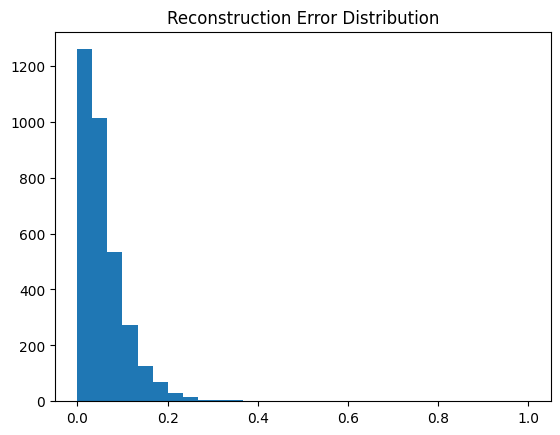

In [52]:
latent_features = encoder.predict(X_scaled)

reconstructions = autoencoder.predict(X_scaled)
reconstruction_error = np.mean(np.square(X_scaled - reconstructions), axis=1)

reconstruction_error = (reconstruction_error - reconstruction_error.min()) / \
                       (reconstruction_error.max() - reconstruction_error.min())

plt.hist(reconstruction_error, bins=30)
plt.title("Reconstruction Error Distribution")
plt.show()

MiniBatch KMeans

In [53]:
kmeans = MiniBatchKMeans(n_clusters=3, batch_size=64, random_state=42)
clusters = kmeans.fit_predict(latent_features)

sil_score = silhouette_score(latent_features, clusters)
db_score = davies_bouldin_score(latent_features, clusters)

print("Silhouette Score:", sil_score)
print("Davies-Bouldin Index:", db_score)

Silhouette Score: 0.2823646
Davies-Bouldin Index: 1.426870768615113


Stable Cluster & Distance Score

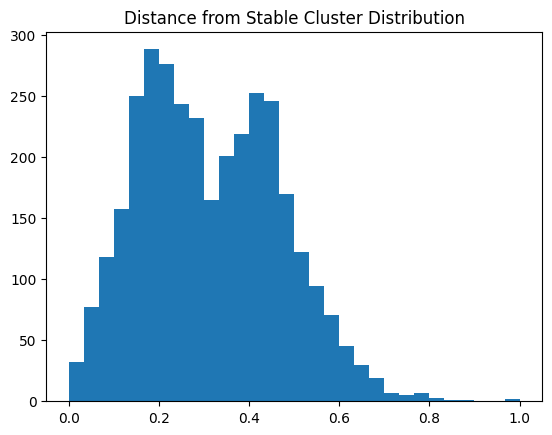

In [54]:
cluster_sizes = pd.Series(clusters).value_counts()
stable_cluster = cluster_sizes.idxmax()

stable_centroid = kmeans.cluster_centers_[stable_cluster]

distance = np.linalg.norm(latent_features - stable_centroid, axis=1)

distance_score = (distance - distance.min()) / (distance.max() - distance.min())

plt.hist(distance_score, bins=30)
plt.title("Distance from Stable Cluster Distribution")
plt.show()

Isolation Forest

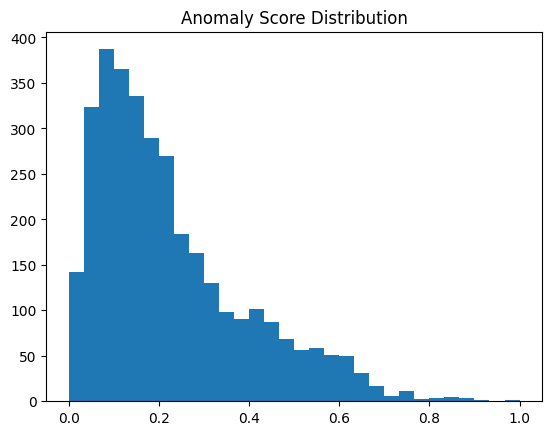

In [55]:
iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(latent_features)

anomaly_score = -iso.score_samples(latent_features)

anomaly_score = (anomaly_score - anomaly_score.min()) / \
                (anomaly_score.max() - anomaly_score.min())

plt.hist(anomaly_score, bins=30)
plt.title("Anomaly Score Distribution")
plt.show()

Drift Score

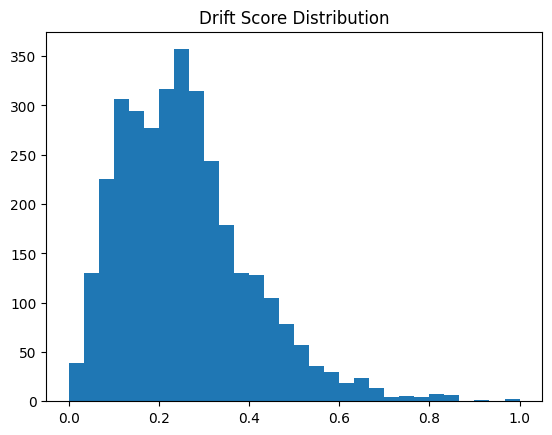

In [56]:
historical_mean = np.mean(latent_features, axis=0)

drift = np.linalg.norm(latent_features - historical_mean, axis=1)

drift_score = (drift - drift.min()) / (drift.max() - drift.min())

plt.hist(drift_score, bins=30)
plt.title("Drift Score Distribution")
plt.show()

Risk Fusion

In [57]:
final_risk = (
    0.4 * distance_score +
    0.3 * anomaly_score +
    0.3 * drift_score
) * 100

def categorize(score):
    if score < 30:
        return "Stable"
    elif score < 70:
        return "At-Risk"
    else:
        return "High-Risk"

results_df = pd.DataFrame({
    "Customer_ID": data["Customer_ID"],
    "Distance_Score": distance_score,
    "Anomaly_Score": anomaly_score,
    "Drift_Score": drift_score,
    "Reconstruction_Error": reconstruction_error,
    "Final_Risk_Score": final_risk
})

results_df["Risk_Category"] = results_df["Final_Risk_Score"].apply(categorize)

results_df.head()

,Customer_ID,Distance_Score,Anomaly_Score,Drift_Score,Reconstruction_Error,Final_Risk_Score,Risk_Category
0,CUST_0,0.566470,0.399244,0.420208,0.019770,47.242353,At-Risk
1,CUST_1,0.497011,0.190114,0.341362,0.046023,35.824711,At-Risk
2,CUST_2,0.278561,0.238271,0.203682,0.045381,24.401041,Stable
3,CUST_3,0.415611,0.421255,0.479646,0.263235,43.651457,At-Risk
4,CUST_4,0.548660,0.541275,0.604713,0.048620,56.326032,At-Risk


Business Summary + Visualization

===== BUSINESS SUMMARY =====
Total Customers: 3333
Risk_Category
Stable       2046
At-Risk      1263
High-Risk      24
Name: count, dtype: int64
Average Risk Score: 27.11


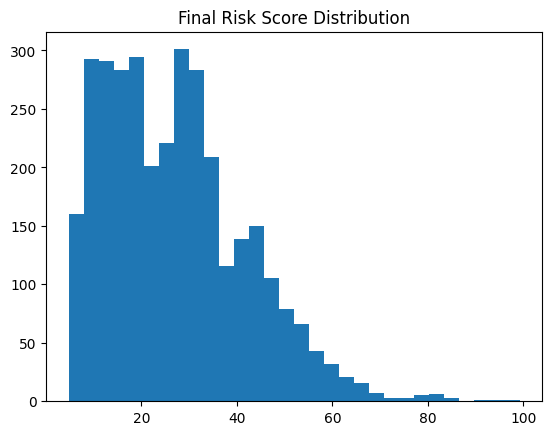

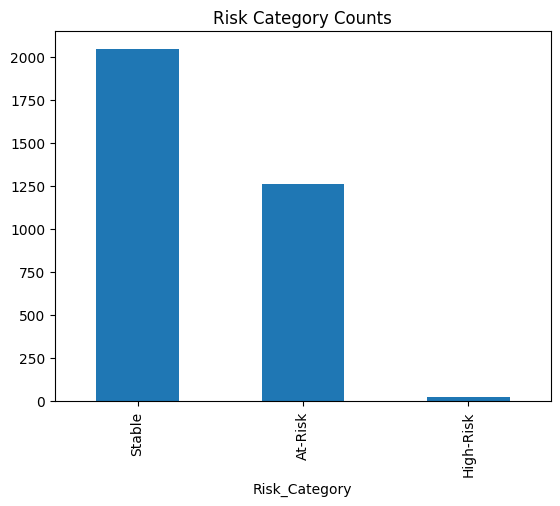

In [58]:
print("===== BUSINESS SUMMARY =====")
print("Total Customers:", len(results_df))
print(results_df["Risk_Category"].value_counts())
print("Average Risk Score:", round(results_df["Final_Risk_Score"].mean(),2))

plt.hist(results_df["Final_Risk_Score"], bins=30)
plt.title("Final Risk Score Distribution")
plt.show()

results_df["Risk_Category"].value_counts().plot(kind='bar')
plt.title("Risk Category Counts")
plt.show()

PCA Visualization with Risk

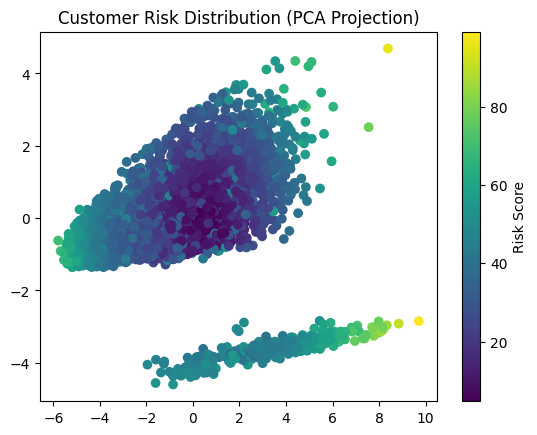

In [59]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(latent_features)

plt.scatter(pca_features[:,0], pca_features[:,1],
            c=results_df["Final_Risk_Score"], cmap="viridis")
plt.colorbar(label="Risk Score")
plt.title("Customer Risk Distribution (PCA Projection)")
plt.show()

Inspect Individual Customer

In [60]:
def show_customer_details(customer_id):
    customer = results_df[results_df["Customer_ID"] == customer_id]

    if customer.empty:
        print("Customer not found")
        return

    display(customer)

# Example
show_customer_details("CUST_3")

,Customer_ID,Distance_Score,Anomaly_Score,Drift_Score,Reconstruction_Error,Final_Risk_Score,Risk_Category
3,CUST_3,0.415611,0.421255,0.479646,0.263235,43.651457,At-Risk


Final CSV

In [61]:
import os
from datetime import datetime

save_path = "/content/drive/MyDrive/SCIQUS_Internship"

os.makedirs(save_path, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
file_path = os.path.join(save_path, f"Final_Customer_Risk_Output_{timestamp}.csv")

results_df.to_csv(file_path, index=False)

print("✅ Final CSV Stored Successfully!")
print(f"📁 Location: {file_path}")
print("\nPreview:")
display(results_df.head())

✅ Final CSV Stored Successfully!
📁 Location: /content/drive/MyDrive/SCIQUS_Internship/Final_Customer_Risk_Output_20260302_114520.csv

Preview:


,Customer_ID,Distance_Score,Anomaly_Score,Drift_Score,Reconstruction_Error,Final_Risk_Score,Risk_Category
0,CUST_0,0.566470,0.399244,0.420208,0.019770,47.242353,At-Risk
1,CUST_1,0.497011,0.190114,0.341362,0.046023,35.824711,At-Risk
2,CUST_2,0.278561,0.238271,0.203682,0.045381,24.401041,Stable
3,CUST_3,0.415611,0.421255,0.479646,0.263235,43.651457,At-Risk
4,CUST_4,0.548660,0.541275,0.604713,0.048620,56.326032,At-Risk


Save Model Bundle

In [62]:
bundle_path = "/content/drive/MyDrive/SCIQUS_Internship/churn_model_bundle"
os.makedirs(bundle_path, exist_ok=True)

autoencoder.save(os.path.join(bundle_path, "autoencoder.h5"))
encoder.save(os.path.join(bundle_path, "encoder.h5"))

joblib.dump(kmeans, os.path.join(bundle_path, "kmeans.pkl"))
joblib.dump(iso, os.path.join(bundle_path, "isolation_forest.pkl"))
joblib.dump(scaler, os.path.join(bundle_path, "scaler.pkl"))

with open(os.path.join(bundle_path, "feature_config.json"), "w") as f:
    json.dump(feature_columns, f)

with open(os.path.join(bundle_path, "stable_cluster_info.json"), "w") as f:
    json.dump({"stable_cluster": int(stable_cluster)}, f)

with open(os.path.join(bundle_path, "risk_fusion_config.json"), "w") as f:
    json.dump({"distance":0.4,"anomaly":0.3,"drift":0.3}, f)

with open(os.path.join(bundle_path, "pipeline_version.yaml"), "w") as f:
    yaml.dump({"version":"3.0_with_customer_tracking"}, f)

print("Model bundle saved.")

Model bundle saved.


Incremental Update

In [63]:
def incremental_update(new_batch_df):

    global historical_mean

    X_new = scaler.transform(new_batch_df[feature_columns])

    autoencoder.fit(X_new, X_new, epochs=5, batch_size=32, verbose=0)

    latent_new = encoder.predict(X_new)

    kmeans.partial_fit(latent_new)

    iso.fit(np.vstack([latent_features, latent_new]))

    historical_mean = np.mean(
        np.vstack([latent_features, latent_new]), axis=0
    )

    print("Incremental update completed.")

# **Evaluating Metrics Calculation**

AUTOENCODER EVALUATION: Training Curve Check/ Training Curve Check

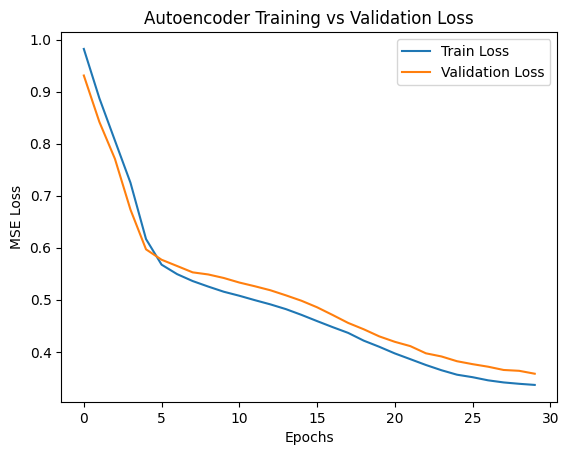

Final Training Loss: 0.33633825182914734
Final Validation Loss: 0.35786858201026917


In [64]:
plt.figure()
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.title("Autoencoder Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()

print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

In [65]:
print("===== Reconstruction Error Statistics =====")
print("Mean:", np.mean(reconstruction_error))
print("Std Dev:", np.std(reconstruction_error))
print("Min:", np.min(reconstruction_error))
print("Max:", np.max(reconstruction_error))

===== Reconstruction Error Statistics =====
Mean: 0.05839582787447731
Std Dev: 0.05134917487743869
Min: 0.0
Max: 1.0


KMEANS CLUSTER EVALUATION: Clustering Quality Metrics/ Cluster Balance Check

In [66]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_score = silhouette_score(latent_features, clusters)
db_score = davies_bouldin_score(latent_features, clusters)

print("===== Clustering Evaluation =====")
print("Silhouette Score:", sil_score)
print("Davies-Bouldin Index:", db_score)

===== Clustering Evaluation =====
Silhouette Score: 0.2823646
Davies-Bouldin Index: 1.426870768615113


===== Cluster Distribution =====
1    0.394239
2    0.376238
0    0.229523
Name: proportion, dtype: float64


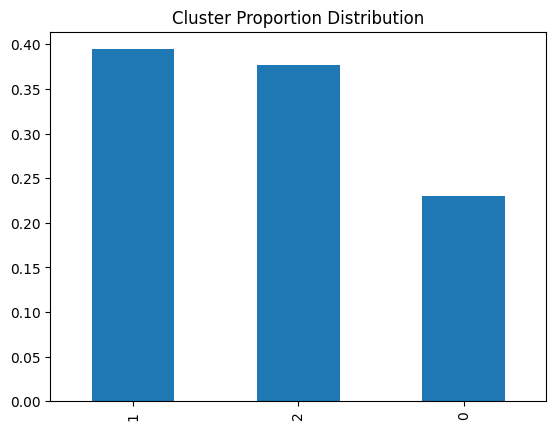

In [67]:
print("===== Cluster Distribution =====")
cluster_distribution = pd.Series(clusters).value_counts(normalize=True)
print(cluster_distribution)

cluster_distribution.plot(kind='bar')
plt.title("Cluster Proportion Distribution")
plt.show()

ISOLATION FOREST EVALUATION: Anomaly Spread Check/ Approximate Anomaly Percentage

In [68]:
print("===== Anomaly Score Statistics =====")
print("Mean:", np.mean(anomaly_score))
print("Std Dev:", np.std(anomaly_score))
print("Min:", np.min(anomaly_score))
print("Max:", np.max(anomaly_score))

===== Anomaly Score Statistics =====
Mean: 0.22595185698604495
Std Dev: 0.168163556023464
Min: 0.0
Max: 1.0


In [69]:
threshold = np.percentile(anomaly_score, 90)
detected_anomalies = np.sum(anomaly_score > threshold)

print("Expected Contamination ~10%")
print("Detected Anomalies:", detected_anomalies)
print("Percentage:", detected_anomalies / len(anomaly_score))

Expected Contamination ~10%
Detected Anomalies: 334
Percentage: 0.1002100210021002


DRIFT DETECTION EVALUATION:

===== Drift Score Statistics =====
Mean: 0.2576512
Std Dev: 0.14380978
Min: 0.0
Max: 1.0


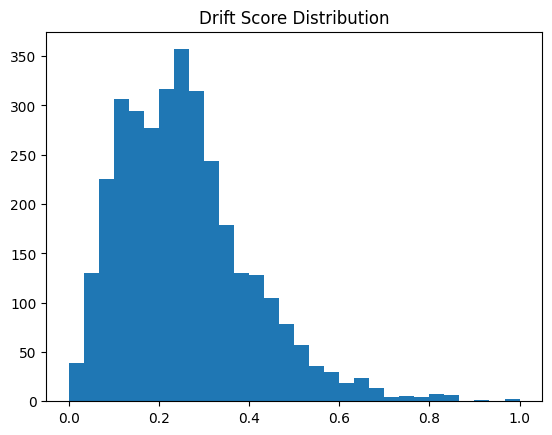

In [70]:
print("===== Drift Score Statistics =====")
print("Mean:", np.mean(drift_score))
print("Std Dev:", np.std(drift_score))
print("Min:", np.min(drift_score))
print("Max:", np.max(drift_score))

plt.hist(drift_score, bins=30)
plt.title("Drift Score Distribution")
plt.show()

FINAL RISK SYSTEM EVALUATION: Risk Score Distribution/ Risk Category Balance

===== Final Risk Score Summary =====
count    3333.000000
mean       27.112267
std        14.706385
min         4.740291
25%        15.158488
50%        25.640017
75%        35.576210
max        99.185069
Name: Final_Risk_Score, dtype: float64


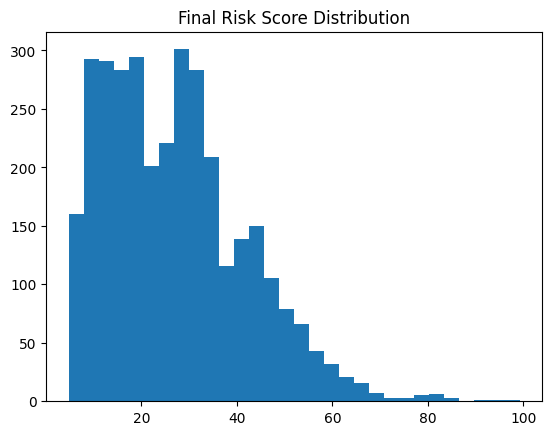

In [71]:
print("===== Final Risk Score Summary =====")
print(results_df["Final_Risk_Score"].describe())

plt.hist(results_df["Final_Risk_Score"], bins=30)
plt.title("Final Risk Score Distribution")
plt.show()

===== Risk Category Distribution =====
Risk_Category
Stable       0.613861
At-Risk      0.378938
High-Risk    0.007201
Name: proportion, dtype: float64


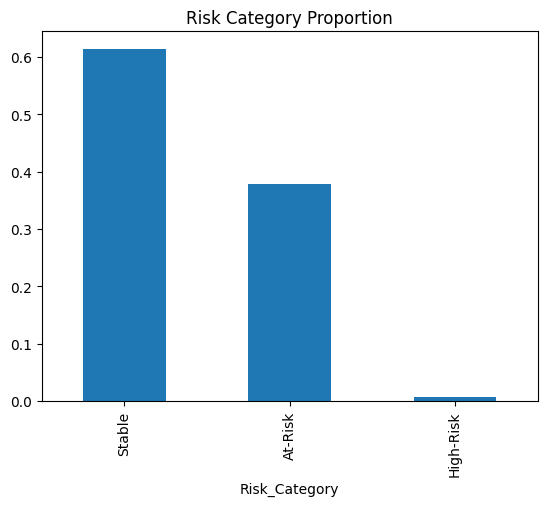

In [72]:
print("===== Risk Category Distribution =====")
category_dist = results_df["Risk_Category"].value_counts(normalize=True)
print(category_dist)

category_dist.plot(kind='bar')
plt.title("Risk Category Proportion")
plt.show()

# INFERENCE TESTING CELL

In [73]:
# ==========================================
# FINAL INFERENCE TESTING USING MODEL BUNDLE
# (UPDATED WITH MSE LOADING FIX)
# ==========================================

import os
import json
import joblib
import numpy as np
import pandas as pd
from datetime import datetime
from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError

# ------------------------------------------
# PATHS
# ------------------------------------------

model_bundle_path = "/content/drive/MyDrive/SCIQUS_Internship/churn_model_bundle"
synthetic_data_path = "/content/drive/MyDrive/SCIQUS_Internship/Datasets/stable_synthetic_data.csv"
output_folder = "/content/drive/MyDrive/SCIQUS_Internship"

# ------------------------------------------
# LOAD MODELS (FIXED FOR MSE ISSUE)
# ------------------------------------------

custom_objects = {
    "mse": MeanSquaredError(),
    "MeanSquaredError": MeanSquaredError
}

autoencoder = load_model(
    os.path.join(model_bundle_path, "autoencoder.h5"),
    custom_objects=custom_objects,
    compile=False
)

encoder = load_model(
    os.path.join(model_bundle_path, "encoder.h5"),
    custom_objects=custom_objects,
    compile=False
)

kmeans = joblib.load(os.path.join(model_bundle_path, "kmeans.pkl"))
iso = joblib.load(os.path.join(model_bundle_path, "isolation_forest.pkl"))
scaler = joblib.load(os.path.join(model_bundle_path, "scaler.pkl"))

with open(os.path.join(model_bundle_path, "feature_config.json"), "r") as f:
    feature_columns = json.load(f)

with open(os.path.join(model_bundle_path, "stable_cluster_info.json"), "r") as f:
    stable_cluster_info = json.load(f)
    stable_cluster = stable_cluster_info["stable_cluster"]

with open(os.path.join(model_bundle_path, "risk_fusion_config.json"), "r") as f:
    fusion_weights = json.load(f)

print("✅ Model bundle loaded successfully.")

# ------------------------------------------
# LOAD SYNTHETIC DATA
# ------------------------------------------

data = pd.read_csv(synthetic_data_path)

# Assign Customer_ID if missing
if "Customer_ID" not in data.columns:
    data["Customer_ID"] = ["SYN_CUST_" + str(i) for i in range(len(data))]

customer_ids = data["Customer_ID"]

# ------------------------------------------
# PREPROCESSING
# ------------------------------------------

X = data[feature_columns]
X_scaled = scaler.transform(X)

# ------------------------------------------
# AUTOENCODER LATENT + RECONSTRUCTION
# ------------------------------------------

latent_features = encoder.predict(X_scaled, verbose=0)
reconstructions = autoencoder.predict(X_scaled, verbose=0)

reconstruction_error = np.mean(np.square(X_scaled - reconstructions), axis=1)
reconstruction_error = (reconstruction_error - reconstruction_error.min()) / \
                       (reconstruction_error.max() - reconstruction_error.min() + 1e-8)

# ------------------------------------------
# DISTANCE FROM STABLE CLUSTER
# ------------------------------------------

stable_centroid = kmeans.cluster_centers_[stable_cluster]

distance = np.linalg.norm(latent_features - stable_centroid, axis=1)
distance_score = (distance - distance.min()) / \
                 (distance.max() - distance.min() + 1e-8)

# ------------------------------------------
# ISOLATION FOREST ANOMALY SCORE
# ------------------------------------------

anomaly_score = -iso.score_samples(latent_features)
anomaly_score = (anomaly_score - anomaly_score.min()) / \
                (anomaly_score.max() - anomaly_score.min() + 1e-8)

# ------------------------------------------
# DRIFT SCORE
# ------------------------------------------

historical_mean = np.mean(kmeans.cluster_centers_, axis=0)

drift = np.linalg.norm(latent_features - historical_mean, axis=1)
drift_score = (drift - drift.min()) / \
              (drift.max() - drift.min() + 1e-8)

# ------------------------------------------
# FINAL RISK FUSION
# ------------------------------------------

final_risk = (
    fusion_weights["distance"] * distance_score +
    fusion_weights["anomaly"] * anomaly_score +
    fusion_weights["drift"] * drift_score
) * 100

# ------------------------------------------
# RISK CATEGORIZATION
# ------------------------------------------

def categorize(score):
    if score < 30:
        return "Stable"
    elif score < 70:
        return "At-Risk"
    else:
        return "High-Risk"

risk_category = [categorize(score) for score in final_risk]

# ------------------------------------------
# CREATE FINAL OUTPUT DATAFRAME
# ------------------------------------------

results_df = pd.DataFrame({
    "Customer_ID": customer_ids,
    "Distance_Score": distance_score,
    "Anomaly_Score": anomaly_score,
    "Drift_Score": drift_score,
    "Reconstruction_Error": reconstruction_error,
    "Final_Risk_Score": final_risk,
    "Risk_Category": risk_category
})

# ------------------------------------------
# SAVE OUTPUT CSV
# ------------------------------------------

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_path = os.path.join(output_folder, f"Inference_Output_{timestamp}.csv")

results_df.to_csv(output_path, index=False)

print("✅ Inference completed successfully.")
print("📁 Output saved at:", output_path)
print("\nPreview:")
display(results_df)

✅ Model bundle loaded successfully.
✅ Inference completed successfully.
📁 Output saved at: /content/drive/MyDrive/SCIQUS_Internship/Inference_Output_20260302_114616.csv

Preview:


,Customer_ID,Distance_Score,Anomaly_Score,Drift_Score,Reconstruction_Error,Final_Risk_Score,Risk_Category
0,SYN_CUST_0,0.322247,0.271027,0.298764,0.166301,29.983592,Stable
1,SYN_CUST_1,0.549832,0.127700,0.412766,0.762821,38.207245,At-Risk
2,SYN_CUST_2,0.183618,0.075551,0.171494,0.452709,14.756062,Stable
3,SYN_CUST_3,0.348434,0.199325,0.225419,0.346798,26.679690,Stable
4,SYN_CUST_4,0.104474,0.029329,0.014078,0.183654,5.481194,Stable
5,SYN_CUST_5,0.383592,0.363671,0.461859,0.118602,40.109580,At-Risk
6,SYN_CUST_6,0.198017,0.051880,0.079010,0.242962,11.847395,Stable
7,SYN_CUST_7,0.266082,0.169174,0.276161,1.000000,24.003313,Stable
8,SYN_CUST_8,0.248133,0.080908,0.064303,0.000000,14.281634,Stable
9,SYN_CUST_9,0.191911,0.223219,0.276544,0.082002,22.669292,Stable
